# Credit Risk Modeling Analysis

## **Data**

**Karakteristik Data**

- Dataset Merupakan data yang dibangkitkan melalui simulasi data. dataset ini mencakup profil demografis dan finansial dari para peminjam. Berisi 1.000 riwayat pengajuan kredit oleh calon debitur (peminjam). Data ini terdiri dari 6 variabel yaitu:

**1. Variabel Prediktor (X):**

- Usia Peminjam: Rentang usia calon debitur (20 hingga 65 tahun).
- Lama Bekerja: Durasi pengalaman kerja peminjam saat ini (0 hingga 30 tahun), sebagai indikator stabilitas pendapatan.
- Suku Bunga Pinjaman: Persentase bunga yang dibebankan pada fasilitas kredit (5% hingga 20%).
- Status Kepemilikan Rumah: Kondisi hunian peminjam (Sewa, KPR, atau Milik Sendiri).
- Tujuan Pinjaman: Alasan pengajuan dana (Kesehatan, Pendidikan, Modal Usaha, atau Konsumtif).

**2. Variabel Target (Y):**

- Status Pinjaman (Target): Indikator performa kredit historis, di mana 1 merepresentasikan pembayaran Lancar dan 0 merepresentasikan Gagal Bayar.

## **Tujuan**

**1. Tujuan Utama (Business Objective):**

- Membangun model prediksi risiko kredit (Probability of Default) yang akurat untuk mengidentifikasi calon peminjam yang berpotensi gagal bayar. Hal ini bertujuan untuk membantu perusahaan meminimalisir risiko kerugian finansial akibat kredit macet (Non-Performing Loan / NPL) dan mengoptimalkan proses persetujuan kredit.

**2. Tujuan Khusus (Technical Objectives):**

- Eksplorasi Profil Risiko: Menganalisis pola dan karakteristik demografis serta finansial dari peminjam historis untuk memahami variabel apa saja yang membedakan peminjam lancar dan gagal bayar.
- Penanganan Data Tidak Seimbang: Mengimplementasikan teknik oversampling (SMOTE) untuk mengatasi ketidakseimbangan kelas (imbalanced data) yang umum terjadi pada data risiko kredit, sehingga model tidak bias terhadap mayoritas peminjam lancar.
- Pemodelan Menggunakan Multiple Regression Logistic: Mengembangkan model klasifikasi menggunakan algoritma Logistic Regression yang mudah diinterpretasikan oleh para stakeholder.
- Evaluasi Metrik Model: Mengukur performa model tidak hanya menggunakan akurasi, tetapi menggunakan metrik standar industri perbankan seperti ROC-AUC, Gini Index, dan KS-Statistic.
- Ekstraksi Wawasan Bisnis (Feature Importance): Menemukan faktor-faktor utama penyumbang risiko untuk dijadikan dasar rekomendasi kebijakan kepada tim Credit Analyst atau Risk Management.

## **Analisis Multiple Regression Logistik**

In [ ]:
# ==========================================
# STEP 1: IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

# untuk Uji Asumsi (Signifikansi P-Value & Multikolinearitas)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [ ]:
# ==========================================
# STEP 2: MEMBANGKITKAN DATA
# ==========================================
np.random.seed(42)
n_samples = 1000

# 1. Membuat data kolom prediktor secara acak
usia = np.random.randint(20, 65, n_samples)
lama_kerja = np.random.randint(0, 30, n_samples)
bunga = np.random.uniform(5.0, 20.0, n_samples)
rumah = np.random.choice(['SEWA', 'MILIK_SENDIRI', 'KPR'], n_samples)
tujuan = np.random.choice(['PENDIDIKAN', 'KESEHATAN', 'MODAL_USAHA', 'KONSUMTIF'], n_samples)

# 2. MENCIPTAKAN POLA: Skor Risiko
skor_risiko = np.zeros(n_samples)
skor_risiko += (bunga * 0.2)             # Bunga tinggi = Risiko naik
skor_risiko -= (lama_kerja * 0.15)       # Lama bekerja = Risiko turun
skor_risiko -= (usia * 0.05)             # Usia matang = Risiko turun
skor_risiko += np.where(rumah == 'SEWA', 1.5, 0)
skor_risiko -= np.where(rumah == 'MILIK_SENDIRI', 1.5, 0)
skor_risiko += np.where(tujuan == 'KONSUMTIF', 1.0, 0)

# Tambahkan noise agar akurasi realistis (~80%)
skor_risiko += np.random.normal(0, 2.5, n_samples)

# 3. Ubah Skor Risiko menjadi probabilitas (0 hingga 1)
probabilitas_gagal = 1 / (1 + np.exp(-skor_risiko))

# 4. Tentukan target (0: Gagal Bayar, 1: Lancar)
batas_threshold = np.percentile(probabilitas_gagal, 80)
status = np.where(probabilitas_gagal > batas_threshold, 0, 1)

df = pd.DataFrame({
    'usia_peminjam': usia,
    'lama_bekerja_tahun': lama_kerja,
    'suku_bunga_pinjaman': bunga,
    'status_kepemilikan_rumah': rumah,
    'tujuan_pinjaman': tujuan,
    'status_pinjaman': status
})

print("--- Distribusi Target (0: Gagal Bayar, 1: Lancar) ---")
print(df['status_pinjaman'].value_counts(normalize=True) * 100)

--- Distribusi Target (0: Gagal Bayar, 1: Lancar) ---
status_pinjaman
1    80.0
0    20.0
Name: proportion, dtype: float64



Step 3: Membuat visualisasi EDA...


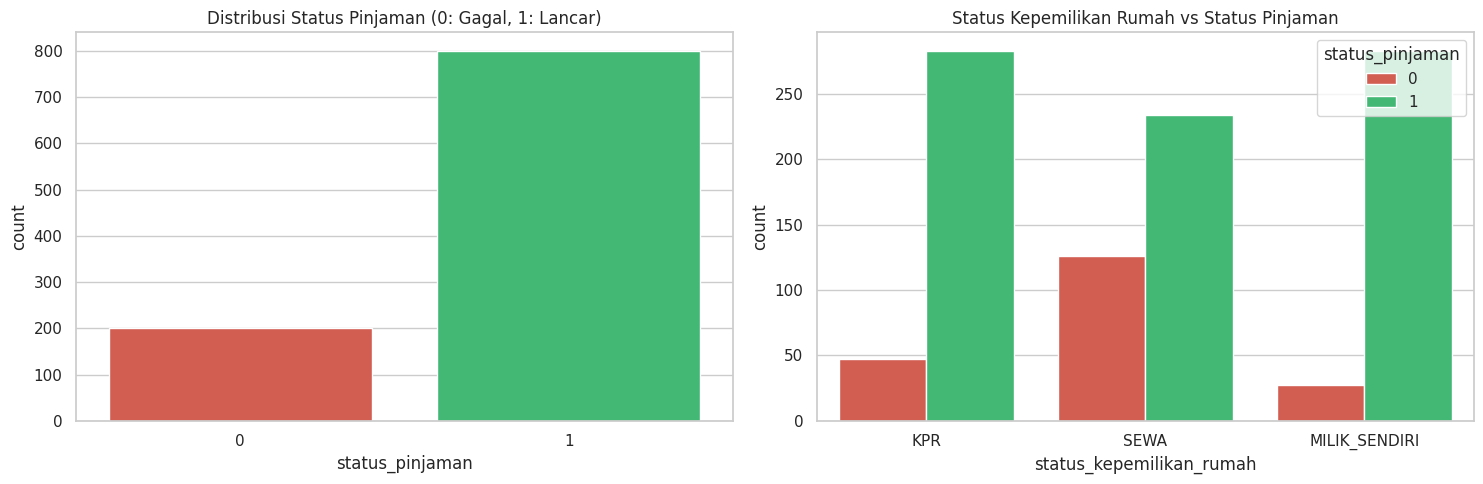

In [ ]:
# ==========================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\nStep 3: Membuat visualisasi EDA...")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
warna_target = {0: '#e74c3c', 1: '#2ecc71'}

sns.countplot(x='status_pinjaman', hue='status_pinjaman', data=df, ax=axes[0], palette=warna_target, legend=False)
axes[0].set_title('Distribusi Status Pinjaman (0: Gagal, 1: Lancar)')

sns.countplot(x='status_kepemilikan_rumah', hue='status_pinjaman', data=df, ax=axes[1], palette=warna_target)
axes[1].set_title('Status Kepemilikan Rumah vs Status Pinjaman')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# STEP 4: PREPROCESSING DATA
# ==========================================
print("\nStep 4: Membersihkan dan memproses data...")

# Memisahkan kolom numerik dan kategorikal
kolom_numerik = ['usia_peminjam', 'lama_bekerja_tahun', 'suku_bunga_pinjaman']
kolom_kategori = ['status_kepemilikan_rumah', 'tujuan_pinjaman']

# Mengubah data kategori menjadi angka (One-Hot Encoding) tipe integer
df_kategori_encoded = pd.get_dummies(df[kolom_kategori], drop_first=True, dtype=int)

# Menggabungkan kembali fitur numerik dan fitur kategori (dummy)
X = pd.concat([df[kolom_numerik], df_kategori_encoded], axis=1)
y = df['status_pinjaman']

print("Bentuk data setelah Encoding:", X.shape)


Step 4: Membersihkan dan memproses data...
Bentuk data setelah Encoding: (1000, 8)


In [ ]:
# ==========================================
# STEP 5: DATA SPLITTING & SCALING & SMOTE
# ==========================================
print("\nStep 5: Split Data, Scaling (hanya numerik), dan SMOTE...")

# 1. Membagi Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Standarisasi (Scaling) HANYA pada kolom numerik agar dummy tetap 0/1
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[kolom_numerik] = scaler.fit_transform(X_train[kolom_numerik])
X_test_scaled[kolom_numerik] = scaler.transform(X_test[kolom_numerik])

# 3. SMOTE (Hanya pada Data Latih)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)


Step 5: Split Data, Scaling (hanya numerik), dan SMOTE...


In [ ]:
# ==========================================
# STEP 6: UJI ASUMSI (MULTIKOLINEARITAS & SIGNIFIKANSI)
# ==========================================
print("\n==========================================")
print("Step 6: UJI ASUMSI STATISTIK")
print("==========================================\n")

# A. UJI MULTIKOLINEARITAS (VIF)
print("--- A. Uji Multikolinearitas (Variance Inflation Factor / VIF) ---")
print("Aturan: Nilai VIF > 5 atau 10 mengindikasikan multikolinearitas yang tinggi.\n")
X_vif = sm.add_constant(X_train_scaled) # Tambahkan konstanta agar hitungan VIF akurat
vif_data = pd.DataFrame()
vif_data["Fitur"] = X_vif.columns
vif_data["Nilai VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data[1:]) # Tampilkan fitur saja (tanpa konstanta)

# B. UJI SIGNIFIKANSI VARIABEL (P-VALUE)
print("\n--- B. Uji Signifikansi Variabel (P-Value) ---")
print("Aturan: Nilai P>|z| (P-Value) di bawah 0.05 berarti variabel tersebut signifikan.\n")
X_train_sm_const = sm.add_constant(X_train_smote)
logit_model = sm.Logit(y_train_smote, X_train_sm_const).fit(disp=0)
print(logit_model.summary())


Step 6: UJI ASUMSI STATISTIK

--- A. Uji Multikolinearitas (Variance Inflation Factor / VIF) ---
Aturan: Nilai VIF > 5 atau 10 mengindikasikan multikolinearitas yang tinggi.

                                    Fitur  Nilai VIF
1                           usia_peminjam   1.005681
2                      lama_bekerja_tahun   1.012158
3                     suku_bunga_pinjaman   1.002376
4  status_kepemilikan_rumah_MILIK_SENDIRI   1.344919
5           status_kepemilikan_rumah_SEWA   1.321624
6               tujuan_pinjaman_KONSUMTIF   1.482884
7             tujuan_pinjaman_MODAL_USAHA   1.500751
8              tujuan_pinjaman_PENDIDIKAN   1.518636

--- B. Uji Signifikansi Variabel (P-Value) ---
Aturan: Nilai P>|z| (P-Value) di bawah 0.05 berarti variabel tersebut signifikan.

                           Logit Regression Results                           
Dep. Variable:        status_pinjaman   No. Observations:                 1280
Model:                          Logit   Df Residuals:     

In [ ]:
# ==========================================
# STEP 7: PEMODELAN ML (LOGISTIC REGRESSION Sckit-Learn)
# ==========================================
print("\nStep 7: Melatih model Logistic Regression (Scikit-Learn)...")
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_smote, y_train_smote)

y_pred = logreg.predict(X_test_scaled)
# Mengekstrak Probabilitas Kelas 0 (Gagal Bayar) untuk evaluasi Risiko
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 0]


Step 7: Melatih model Logistic Regression (Scikit-Learn)...



Step 8: Evaluasi Model (Credit Risk Metrics)...
--- Laporan Klasifikasi (Classification Report) ---
              precision    recall  f1-score   support

           0       0.44      0.72      0.55        40
           1       0.92      0.77      0.84       160

    accuracy                           0.76       200
   macro avg       0.68      0.75      0.69       200
weighted avg       0.82      0.76      0.78       200



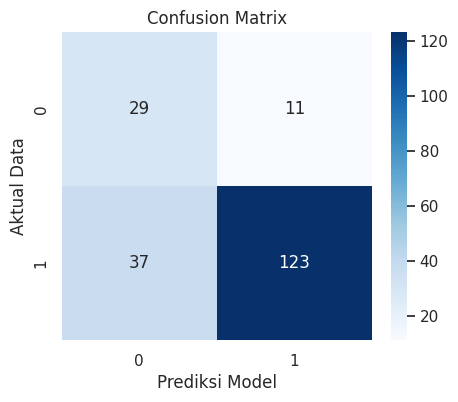

-> ROC-AUC Score : 0.7881 (Target ~ 0.80)
-> Gini Index    : 0.5762
-> KS Statistic  : 0.5625


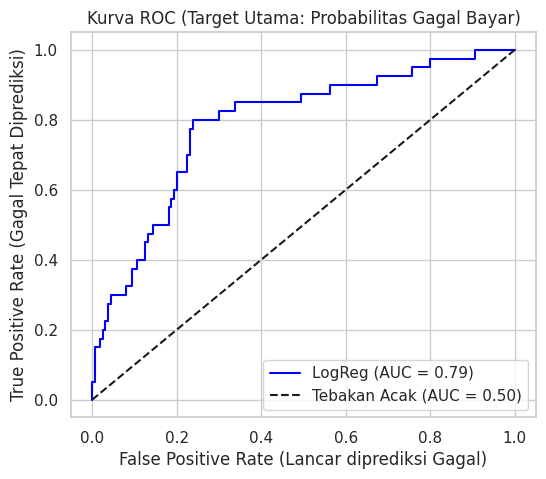

In [ ]:
# ==========================================
# STEP 8: EVALUASI METRIK RISIKO KREDIT
# ==========================================
print("\nStep 8: Evaluasi Model (Credit Risk Metrics)...")
print("--- Laporan Klasifikasi (Classification Report) ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual Data')
plt.show()

# INVERSI TARGET: Balik nilai aktual agar class 0 (Gagal) jadi class positif di ROC-AUC
y_test_eval = 1 - y_test

roc_auc = roc_auc_score(y_test_eval, y_pred_proba)
gini = (2 * roc_auc) - 1

proba_default = y_pred_proba[y_test == 0]
proba_non_default = y_pred_proba[y_test == 1]
ks_stat, p_value = ks_2samp(proba_default, proba_non_default)

print(f"-> ROC-AUC Score : {roc_auc:.4f} (Target ~ 0.80)")
print(f"-> Gini Index    : {gini:.4f}")
print(f"-> KS Statistic  : {ks_stat:.4f}")

fpr, tpr, thresholds = roc_curve(y_test_eval, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'LogReg (AUC = {roc_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Tebakan Acak (AUC = 0.50)')
plt.xlabel('False Positive Rate (Lancar diprediksi Gagal)')
plt.ylabel('True Positive Rate (Gagal Tepat Diprediksi)')
plt.title('Kurva ROC (Target Utama: Probabilitas Gagal Bayar)')
plt.legend(loc='lower right')
plt.show()


Step 9: Menarik Kesimpulan Bisnis...


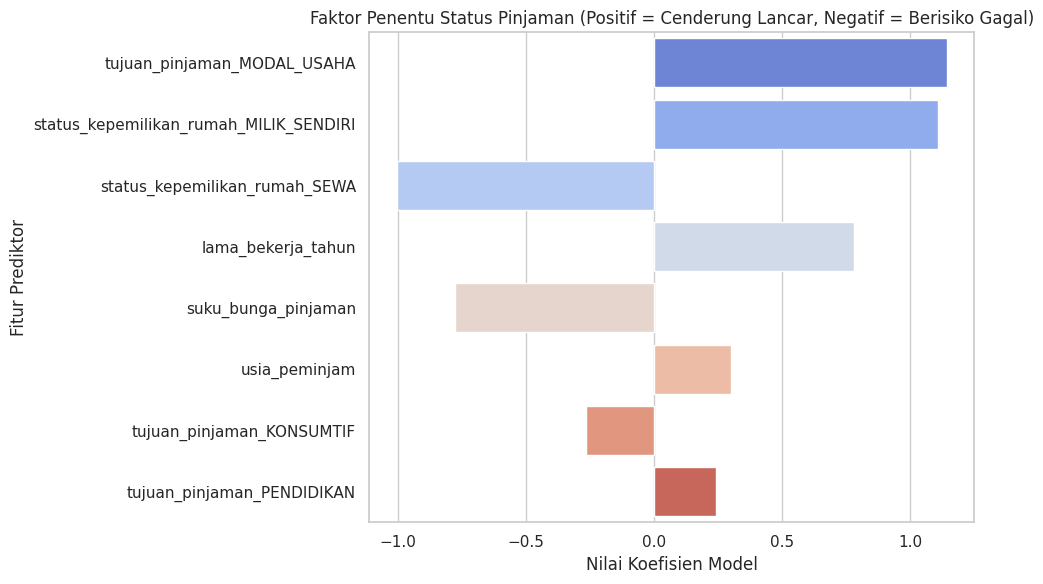

In [ ]:
# ==========================================
# STEP 9: BUSINESS INSIGHT (FEATURE IMPORTANCE)
# ==========================================
print("\nStep 9: Menarik Kesimpulan Bisnis...")
feature_names = X.columns
coefficients = logreg.coef_[0]

feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='coolwarm')
plt.title('Faktor Penentu Status Pinjaman (Positif = Cenderung Lancar, Negatif = Berisiko Gagal)')
plt.xlabel('Nilai Koefisien Model')
plt.ylabel('Fitur Prediktor')
plt.tight_layout()
plt.show()

Berdasarkan Visualisasi diatas dapat di interpretasikan sebagai berikut:

<font color="orange">**- Variabel Numerik**</font>

1. Lama_bekerja_tahun (<font color="#00FF00">**Koefisien Positif**</font>):

Masa kerja yang lama merupakan faktor yang signifikan dalam mendorong kelancaran pembayaran (menurunkan risiko). Semakin lama masa kerja seorang nasabah, maka kemungkinan mereka untuk lancar membayar akan semakin meningkat. Artinya, masa kerja yang panjang mencerminkan stabilitas pekerjaan dan kepastian pendapatan bulanan (gaji rutin), sehingga kapasitas membayar cicilan sangat terjamin.

2. Suku_bunga_pinjaman (<font color="red">**Koefisien Negatif**</font>):

Suku bunga merupakan faktor numerik pemicu risiko gagal bayar terbesar di dalam model. Semakin tinggi persentase suku bunga pinjaman yang ditetapkan, maka kemungkinan nasabah tersebut gagal bayar akan semakin meningkat tajam. Artinya, beban bunga yang terlalu tinggi akan membuat cicilan bulanan membengkak, yang pada akhirnya bisa mencekik arus kas (cash flow) nasabah dan memicu kemacetan pembayaran.

3. Usia_peminjam (<font color="#00FF00">**Koefisien Positif**</font>):

Semakin bertambah usia calon peminjam, kemungkinan mereka untuk berstatus lancar akan semakin meningkat. Artinya, nasabah yang lebih tua umumnya dianggap lebih matang secara finansial, memiliki tabungan, dan lebih bertanggung jawab terhadap utang dibandingkan nasabah yang sangat muda.

---------------------------------------------------------------------------------------------
<font color="orange">**- Variabel Kategorikal**</font>

1. Tujuan_pinjaman_MODAL_USAHA (<font color="#00FF00">**Koefisien Positif**</font>) dengan (Baseline: KESEHATAN):

Meminjam untuk modal usaha memiliki kecenderungan status pinjaman yang sangat lancar dibandingkan pinjaman untuk kesehatan. Bahkan, fitur ini menjadi faktor penentu kelancaran pembayaran paling besar secara keseluruhan di dalam model. Artinya, modal usaha murni bersifat produktif karena uang yang dipinjam langsung digunakan untuk memutar bisnis. Perputaran uang dan keuntungan dari bisnis inilah yang secara langsung meningkatkan kapasitas pendapatan nasabah untuk membayar cicilan dengan lancar.

2. Status_kepemilikan_rumah_MILIK_SENDIRI (<font color="#00FF00">**Koefisien Positif**</font>) dengan (Baseline: KPR):

Nasabah yang sudah memiliki rumah atas namanya sendiri memiliki peluang lancar bayar yang sangat tinggi (tertinggi kedua secara keseluruhan di model). Artinya, kepemilikan aset rumah (tanpa cicilan KPR) menunjukkan kondisi ekonomi yang sangat stabil dan mapan jika dibandingkan dengan nasabah KPR.

3. Status_kepemilikan_rumah_SEWA (<font color="red">**Koefisien Negatif**</font>) dengan (Baseline: KPR):

Nasabah yang berstatus menyewa rumah/kontrak memiliki risiko gagal bayar yang sangat tinggi, bahkan menjadi pemicu risiko gagal bayar terbesar secara keseluruhan di dalam model. Dibandingkan dengan nasabah yang sedang mencicil rumah (KPR), nasabah yang menyewa rumah memiliki pengeluaran tambahan tetap (uang sewa) dan dianggap kurang menetap secara aset.

4. Tujuan_pinjaman_KONSUMTIF (<font color="red">**Koefisien Negatif**</font>) dengan (Baseline: KESEHATAN):

Meminjam untuk tujuan konsumtif memiliki risiko gagal bayar yang lebih tinggi dibandingkan meminjam untuk alasan kesehatan. Artinya, kredit konsumtif (seperti liburan atau gadget) tidak menghasilkan uang kembali (return on investment), sehingga murni menjadi beban utang.

5. Tujuan_pinjaman_PENDIDIKAN (<font color="#00FF00">**Koefisien Positif**</font>) dengan (Baseline: KESEHATAN):

Meminjam untuk pendidikan juga memiliki kecenderungan status pinjaman yang lebih lancar dibandingkan pinjaman untuk kesehatan, meskipun daya dorongnya tidak sekuat modal usaha. Artinya, pendidikan dipandang sebagai investasi masa depan yang produktif. Walaupun tidak menghasilkan uang secara instan di hari itu juga, peningkatan ilmu atau gelar akademis diharapkan akan membuka peluang karier dan gaji yang lebih baik, sehingga meningkatkan stabilitas finansial nasabah dalam jangka panjang.

## Kesimpulan

1. Profil Nasabah "Aman" (<font color="#00FF00">**Rekomendasi untuk Disetujui**</font>)

Kandidat peminjam yang paling ideal dan memiliki probabilitas tertinggi untuk lancar membayar adalah mereka yang mengajukan kredit untuk modal usaha (faktor pendorong kelancaran tertinggi) dan telah memiliki rumah atas nama sendiri (faktor pengaman terkuat kedua). Profil ini akan semakin solid jika didukung oleh masa kerja yang sudah lama (stabilitas pendapatan) dan usia yang lebih matang. Pinjaman untuk tujuan pendidikan juga masuk dalam kategori produktif yang aman. Bank disarankan untuk memprioritaskan persetujuan pada profil ini dan memastikan suku bunga yang diberikan berada di level yang wajar agar kapasitas bayar (repayment capacity) mereka tetap terjaga.

2. Profil Nasabah "Berisiko Tinggi" (<font color="red">**Rekomendasi untuk Ditolak / Diperketat**</font>)

Bank harus sangat waspada dan menerapkan mitigasi berlapis—atau bahkan penolakan—terhadap calon peminjam yang status tempat tinggalnya masih menyewa (ini adalah faktor pemicu gagal bayar paling fatal di dalam model). Risiko kemacetan kredit akan semakin meledak jika nasabah dengan profil ini dibebankan suku bunga pinjaman yang tinggi dan meminjam dana murni untuk kebutuhan konsumtif (gaya hidup tanpa return). Selain itu, nasabah yang masih muda dengan masa kerja yang singkat (belum stabil) juga perlu diawasi lebih ketat karena berkontribusi pada tingginya risiko gagal bayar.